In [21]:
# # Learning from Small Data: Challenge 1 - Statistical Instability
# 
# 1. **Unstable Performance Estimates**: The reported accuracy fluctuates wildly with small datasets.
# 2. **Unstable Model (Sensitivity)**: The model's predictions change dramatically with small changes in the training data.
# **Key Question:** Why can't we trust models trained on tiny datasets?

# %% 1. Setup and Imports
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
import warnings
import time
from sklearn.utils import shuffle
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [3]:
# %% 2. Load and Prepare MNIST Dataset
# Load MNIST (using a subset for speed)
print("Loading MNIST dataset...")
X, y = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=False, parser='pandas')

# Convert to appropriate types
X = X.astype(np.float32)
y = y.astype(np.int32)

# Normalize pixel values to [0, 1]
X = X / 255.0

# Use only first 10,000 samples for faster computation
X = X[:10000]
y = y[:10000]

print(f"Dataset shape: X: {X.shape}, y: {y.shape}")
print(f"Number of classes: {len(np.unique(y))}")

# Split into train (70%) and test (30%)
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Training set: {X_train_full.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Loading MNIST dataset...
Dataset shape: X: (10000, 784), y: (10000,)
Number of classes: 10
Training set: 7000 samples
Test set: 3000 samples


In [25]:
# %% 3. Compare: Abundant Data vs. Small Data
# We first show how a model trained on **reasonable data** (e.g., 2000 samples) performs well and stably, 
# while a model trained on **very small data** (e.g., 2 samples per class) is unstable.

# Define the amount of data to use
ABUNDANT_SIZE = 2000  # "Reasonable" amount of data
SMALL_SIZE = 20       # 2 samples per class (10 classes x 2 = 20)
AVerage_SIZE=100

def sample_small_data(X_full, y_full, n_samples_per_class=2, random_seed=None):
    """Sample exactly n_samples_per_class from each class."""
    if random_seed is not None:
        np.random.seed(random_seed)
    
    indices = []
    for class_label in range(10):
        class_indices = np.where(y_full == class_label)[0]
        # If there are fewer samples than requested, use all available
        n_to_sample = min(n_samples_per_class, len(class_indices))
        selected = np.random.choice(class_indices, size=n_to_sample, replace=False)
        indices.extend(selected)
    
    return X_full[indices], y_full[indices]

def train_and_evaluate(X_train, y_train, X_test, y_test, n_runs=10, is_small=False):
    """Train a logistic regression model and return test accuracies."""
    accuracies = []
    models = []  # Store models for later analysis
    
    for run in range(n_runs):
        if is_small:
            # Sample SMALL_SIZE samples (2 per class) with different random seeds
            X_subset, y_subset = sample_small_data(
                X_train, y_train, 
                n_samples_per_class=2, 
                random_seed=run * 100 + 42
            )
        else:
            # Use the fixed abundant dataset
            X_subset = X_train
            y_subset = y_train
        
        # Standardize features
        scaler = StandardScaler()
        X_subset_scaled = scaler.fit_transform(X_subset)
        X_test_scaled = scaler.transform(X_test)
        
        # Train model
        model = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
        model.fit(X_subset_scaled, y_subset)
        
        # Evaluate
        y_pred = model.predict(X_test_scaled)
        acc = accuracy_score(y_test, y_pred)
        accuracies.append(acc)
        models.append(model)
    
    return accuracies, models

In [29]:
# ### 4.1 Abundant Data: Stable Performance

print("=" * 60)
print("ABUNDANT DATA EXPERIMENT: 2000 training samples")
print("=" * 60)

# Select first ABUNDANT_SIZE samples (or use all if smaller)
X_abundant = X_train_full[:min(ABUNDANT_SIZE, len(X_train_full))]
y_abundant = y_train_full[:min(ABUNDANT_SIZE, len(y_train_full))]

acc_abundant, models_abundant = train_and_evaluate(
    X_abundant, y_abundant, X_test, y_test, n_runs=10, is_small=False
)

print(f"Accuracies from 10 runs: {[f'{acc:.3f}' for acc in acc_abundant]}")
print(f"Mean accuracy: {np.mean(acc_abundant):.4f} ± {np.std(acc_abundant):.4f}")

# ### 4.2 Small Data

print("=" * 60)
print("Average DATA EXPERIMENT: 100 training samples")
print("=" * 60)

# Select first ABUNDANT_SIZE samples (or use all if smaller)
X_AVerage_SIZE = X_train_full[:min(AVerage_SIZE, len(X_train_full))]
y_AVerage_SIZE = y_train_full[:min(AVerage_SIZE, len(y_train_full))]

acc_AVerage_SIZE, models_AVerage_SIZE = train_and_evaluate(
    X_AVerage_SIZE, y_AVerage_SIZE, X_test, y_test, n_runs=10, is_small=False
)

print(f"Accuracies from 10 runs: {[f'{acc:.3f}' for acc in acc_AVerage_SIZE]}")
print(f"Mean accuracy: {np.mean(acc_AVerage_SIZE):.4f} ± {np.std(acc_AVerage_SIZE):.4f}")


# ### 4.3 Smaller Data: Unstable Performance

print("=" * 60)
print("SMALL DATA EXPERIMENT: 2 samples per class (20 total)")
print("=" * 60)

# Use the same function with is_small=True
acc_small, models_small = train_and_evaluate(
    X_train_full, y_train_full, X_test, y_test, n_runs=10, is_small=True
)

print(f"Accuracies from 10 runs: {[f'{acc:.3f}' for acc in acc_small]}")
print(f"Mean accuracy: {np.mean(acc_small):.4f} ± {np.std(acc_small):.4f}")

ABUNDANT DATA EXPERIMENT: 2000 training samples
Accuracies from 10 runs: ['0.863', '0.863', '0.863', '0.863', '0.863', '0.863', '0.863', '0.863', '0.863', '0.863']
Mean accuracy: 0.8630 ± 0.0000
Average DATA EXPERIMENT: 100 training samples
Accuracies from 10 runs: ['0.727', '0.727', '0.727', '0.727', '0.727', '0.727', '0.727', '0.727', '0.727', '0.727']
Mean accuracy: 0.7270 ± 0.0000
SMALL DATA EXPERIMENT: 2 samples per class (20 total)
Accuracies from 10 runs: ['0.482', '0.469', '0.474', '0.476', '0.503', '0.490', '0.507', '0.506', '0.469', '0.540']
Mean accuracy: 0.4916 ± 0.0213


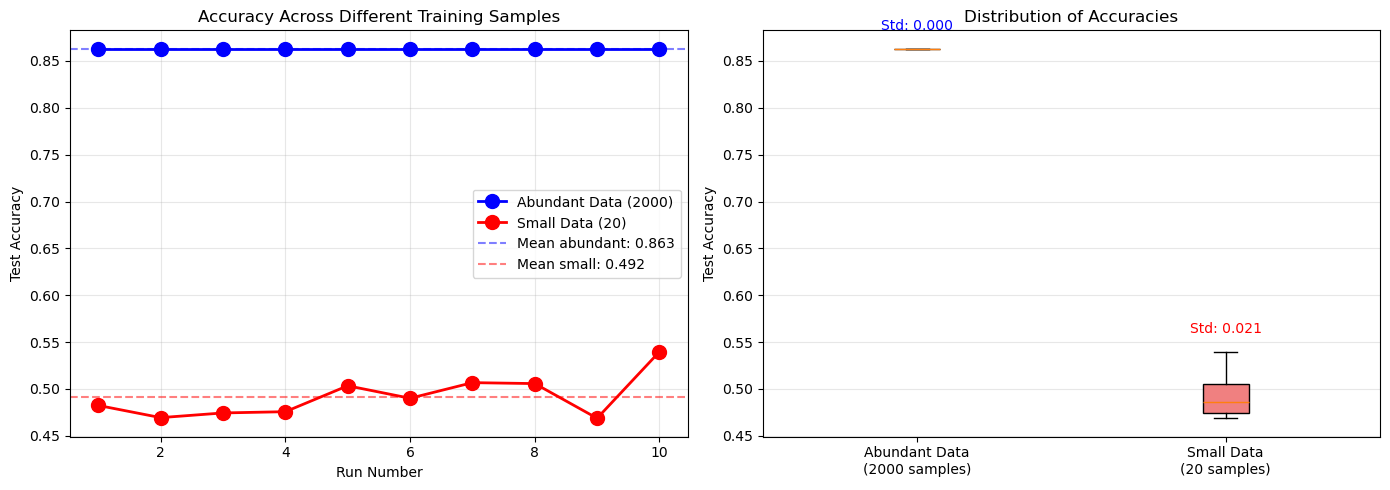

In [31]:
# Create comparison plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Individual accuracies
ax1.plot(range(1, 11), acc_abundant, 'o-', label='Abundant Data (2000)', color='blue', linewidth=2, markersize=10)
ax1.plot(range(1, 11), acc_small, 'o-', label='Small Data (20)', color='red', linewidth=2, markersize=10)
ax1.axhline(y=np.mean(acc_abundant), color='blue', linestyle='--', alpha=0.5, label=f'Mean abundant: {np.mean(acc_abundant):.3f}')
ax1.axhline(y=np.mean(acc_small), color='red', linestyle='--', alpha=0.5, label=f'Mean small: {np.mean(acc_small):.3f}')
ax1.set_xlabel('Run Number')
ax1.set_ylabel('Test Accuracy')
ax1.set_title('Accuracy Across Different Training Samples')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Box plot comparison
box_data = [acc_abundant, acc_small]
bp = ax2.boxplot(box_data, labels=['Abundant Data\n(2000 samples)', 'Small Data\n(20 samples)'], patch_artist=True)
bp['boxes'][0].set_facecolor('lightblue')
bp['boxes'][1].set_facecolor('lightcoral')
ax2.set_ylabel('Test Accuracy')
ax2.set_title('Distribution of Accuracies')
ax2.grid(True, alpha=0.3, axis='y')

# Add text annotations
ax2.text(1, np.max(acc_abundant) + 0.02, f'Std: {np.std(acc_abundant):.3f}', ha='center', color='blue')
ax2.text(2, np.max(acc_small) + 0.02, f'Std: {np.std(acc_small):.3f}', ha='center', color='red')

plt.tight_layout()
plt.savefig('instability_comparison.png', dpi=150, bbox_inches='tight')
plt.show()